## Artificial intelligence-enabled electrocardiogram to detect digoxin exposure 
#### Inference Notebook 

In [15]:
from __future__ import annotations
import os         
import os
import json
import sys
import re
import copy
import random
from tqdm import tqdm
import ast
%load_ext autoreload
%autoreload 2
import random
from pathlib import Path
import math
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score, average_precision_score
from ml4h.defines import PARTNERS_DATETIME_FORMAT, ECG_REST_AMP_LEADS
from ml4h.TensorMap import TensorMap, Interpretation
print(ECG_REST_AMP_LEADS)
import ecg2dig 
from ecg2dig.utils.datasets import ECGDrugDataset, ECGDataDescription
from ecg2dig.inference import inference
from ecg2dig.utils.datasets import is_valid_ecg, is_bound_ecg, safe_pearsonr
from ecg2dig.utils.helpers import load_model_from_weights, build_model_kwargs_from_log
from ecg2dig.utils.helpers import plot_roc_curves, subgroup_analysis
from ecg2dig.utils.transforms import (ScaleECGTransform, 
                                     ToTensorTransform, 
                                     StandardizeByChannelECGTransform, 
                                     ClipECGByPercentileTransform,
                                     StandardizeTransform)
from ecg2dig.ECG2DIG import ECG2DIG

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{'I': 0, 'II': 1, 'III': 2, 'aVR': 3, 'aVL': 4, 'aVF': 5, 'V1': 6, 'V2': 7, 'V3': 8, 'V4': 9, 'V5': 10, 'V6': 11}


In [11]:
REPO_ROOT = Path.cwd()
ROOT_DIR = '/data/cvrepo/' 
print(ROOT_DIR)
device = 'cpu'

/data/cvrepo/


In [4]:
def _load_data(filepath:str, 
                 verbose:bool = False,
                 dig_threshold:float = 0.,
                 drop_duplicates:bool = False,
                 use_multi_class:bool = False,
                 randomize_hr:bool = False,
                 ):

    try:
        df = pd.read_csv(filepath, sep='\t', 
                         encoding='iso-8859-1', 
                         low_memory=False)  
        
        # Restore dtypes
        df['ecg_datetime'] = pd.to_datetime(df['ecg_datetime'])
        df['measurement_datetime'] = pd.to_datetime(df['measurement_datetime'])
            
        print(df.head(1))

        # create binary OR 3-way variable
        if use_multi_class:
            df['high_digoxin'] = np.select([
                                (df['dig_level'] == 0),
                                (df['dig_level'] > 0) & (df['dig_level'] <= 2),
                                (df['dig_level'] > 2)],
                                [0, 1, 2],
                                default=np.nan
                                ).astype('int8') 
            # where Class 0: dig_level == 0, Class 1: 0 < dig_level ≤ 2, 
            # and Class 2: dig_level  > 2'
            print(f'Created 3-way variable: "high_digoxin"')
        else:   
            df["high_digoxin"] = df.dig_level > dig_threshold
            print(f'Created binary variable: "high_digoxin" with threshold: {dig_threshold}')

        print(df.shape)
        print(df.high_digoxin.value_counts())

        if drop_duplicates: 
            # Sort the dataframe by high_digoxin in descending order (2, 1, 0)
            # then by date descending as a tiebreaker
            # Then drop duplicates in the 'EMPI' column, 
            # keeping only the first occurrence 
            # (which will be the highest priority high_digoxin value)
            print(f'Dropping duplicates..(shape before): {df.shape}')
            print(df.high_digoxin.value_counts())
            df = df.sort_values(['high_digoxin', 'ecg_datetime'], 
                                ascending=[False, False]).drop_duplicates(subset=['EMPI'])
            print(f'After drop duplicates: {df.shape}')
            print(df.high_digoxin.value_counts())
            # Reset the index if needed
            df = df.reset_index(drop=True)        
        print(f'Dataset of shape {df.shape} loaded. Features: {list(df.columns)}')
        return df
    
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
    except pd.errors.ParserError:
        print(f"Error: Failed to parse CSV file at {filepath}. Check the file format.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    
    return None

def create_dataloader(
            ROOT_DIR: str, 
            val_path: str, 
            batch_size: int, 
            meta_columns: Optional[List[str]] = None, 
            use_multi_class = False,
            dig_threshold: float = 0.,
            workers = 0,
            verbose = True,
    ) -> DataLoader:
    
    """
    Creates val dataloader for inference
    Args:
        ROOT_DIR (str): Root dir e.g for ERISXDL:'/data/cvrepo/'
        batch_size (int): Batch size of the loader to create
        val_path (str): Path to the validation pandas dataset file (e.g. csv)
        meta_columns (list): Optional other features besides ecg, digoxin, 
        
        NOTE: the classification variable high_digoxin is added to the dataset
    """
    
    val_df = _load_data(os.path.join(
                        ROOT_DIR, val_path), 
                        dig_threshold = dig_threshold,
                        use_multi_class = use_multi_class,
                        drop_duplicates = False) 
    
    assert val_df is not None, "val_df is None: check data split/loading in get_dataloaders()"

    # ------
    # 1 - non-ECG Transforms
    # Calculate statistics 
    # --------
    
    feature_names = ['age_at_ecg_days', 'dig_level'] 
    print(f'Feature names ={feature_names}')
    print(f'meta columns ={meta_columns}')   

    print(f'Standardizing features: {feature_names}')
    
    # Calculate statistics 
    feature_means = {feat: val_df[feat].mean() for feat in feature_names}
    feature_stds  = {feat: val_df[feat].std()  for feat in feature_names}
    
    if verbose:
        print('Checking transformed values')
        for key, value in feature_means.items():
            if key == 'age_at_ecg_days':
                print(f"{key} (mean): {value/365:.3f}")
            else: 
                print(f"{key} (mean): {value:.3f}")

        for key, value in feature_stds.items():
            if key == 'age_at_ecg_days':
                print(f"{key} (std): {value/365:.3f}")
            else: 
                print(f"{key} (std): {value:.3f}")
    
    # Create the non-ECG transforms combination
    standardize_transform = transforms.Compose([
                    StandardizeTransform(feature_means, feature_stds),
                   ])
    # ------
    # 2 - ECG Transforms 
    # ------
    ecg_transform = transforms.Compose([
            ToTensorTransform(), # Tensor [T, C], still in raw values (e.g.3000)
            ScaleECGTransform(), # Tensor [T, C], now in millivolts
            ClipECGByPercentileTransform(),
            ])

    print(f'ECG Transforms: {ecg_transform}')
    
    # ml4h ECG Tensor and Transforms
    ecg_tmap = TensorMap(
        'ecg_5000_std',
        Interpretation.CONTINUOUS,
        shape=(5000, 12),
    )

    ecg_dd = ECGDataDescription(
            f'{ROOT_DIR}ecgs/',  # folder with MRN_path.h5 files
            name=ecg_tmap.input_name(), 
            ecg_len=5000,  # ECGs linearly interpolated to this length 
            transforms=ecg_transform  
            )
    
    labels = val_df["high_digoxin"].to_numpy(dtype=np.int64)
           
    val_dataset = ECGDrugDataset(
                        dataframe=val_df, 
                        ecg_dataset=ecg_dd,
                        meta_columns=meta_columns,
                        transform=standardize_transform,
                        ecg_transform=ecg_transform,
    )
    
    def safe_collate(batch):
        """Drop None samples from batch"""
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None  
        return torch.utils.data.dataloader.default_collate(batch)
    
    loader = DataLoader(
                    dataset=val_dataset, 
                    batch_size=batch_size, 
                    drop_last=False,
                    shuffle=False,  # We do not want shuffling here 
                    pin_memory=False,
                    num_workers=workers,
                    collate_fn=safe_collate
                    )
    return loader

### Loading datasets

Requirements:

**A pandas .tsv file contaning a dataframe with the following columns:**

- MRN_path
- ecg_datetime
- measurement_datetime <- only used to find the ecg_datetime within 24 h
- dig_level <- digoxin numeric level e.g. 0.2

```
ecg_dd = ECGDataDescription(
        f'{ROOT_DIR}ecgs/',  # folder with MRN_path.h5 files
        name=ecg_tmap.input_name(), 
        ecg_len=5000,  # ECGs linearly interpolated to this length 
        transforms=ecg_transform  
        )
MRN_path = ecg_bwh_hd5s/72389
```

The model was trained as a **3-class classifier (num_classes=3)**.<BR>
- use_multi_class: True
- num_classes: 3 (no dig / therapeutic / suprather).
- dig_threshold: 0 - ignored

In [5]:
use_multi_class = True

In [6]:
# ================
# TOY SET FOR for demo purposes
# measurement_datetime is nan for control group
# ================

val_path = Path(REPO_ROOT / 'val_digoxin_dummy.tsv')
val_df = pd.read_csv(val_path, sep='\t')
val_df['ecg_datetime'] = pd.to_datetime(val_df['ecg_datetime'], errors='coerce')
val_df['ecg_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')
val_df['measurement_datetime'] = pd.to_datetime(val_df['measurement_datetime'], errors='coerce')
val_df['measurement_datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')
print(val_df.shape)
val_df.head()

(9, 6)


,MRN_path,ecg_datetime,measurement_datetime,dig_level,age_at_ecg_days,female
0,ecg_mgh_hd5s/5121213,2012-02-13 16:12:00,NaT,0.0,16068,0
1,ecg_mgh_hd5s/3413260,2016-11-06 10:52:11,NaT,0.0,18717,1
2,ecg_bwh_hd5s/2781425,2004-06-11 16:19:33,2004-06-11 15:15:00,2.1,24952,0
3,ecg_mgh_hd5s/4843934,2017-08-10 13:46:11,2017-08-10 16:24:00,2.3,31065,1
4,ecg_mgh_hd5s/1422157,1986-08-26 18:22:00,NaT,0.0,20045,1


In [7]:
# check time difference - should return empty
mask = (val_df['ecg_datetime'] - val_df['measurement_datetime']).abs() > pd.Timedelta(hours=24)
df_exceeds = val_df[mask]
print(f"{len(df_exceeds)} rows exceed 24 hours")
df_exceeds.head()

0 rows exceed 24 hours


,MRN_path,ecg_datetime,measurement_datetime,dig_level,age_at_ecg_days,female


**'ecg_datetime' should be within 24 hours of the 'meaasurement_datetime'**

In [8]:
#val_path = ROOT_DIR + 'eleni/digoxin/val_combo_no_zero.tsv'
meta_columns = []
batch_size = 256
val_loader = create_dataloader(
                    ROOT_DIR = ROOT_DIR, 
                    batch_size = batch_size, 
                    val_path = val_path, 
                    meta_columns = meta_columns,
                    use_multi_class = True,
                    workers = 0,
                    verbose = True)
len(val_loader) 
val_df = val_loader.dataset.df
val_df.head(2)

               MRN_path        ecg_datetime measurement_datetime  dig_level  \
0  ecg_mgh_hd5s/5121213 2012-02-13 16:12:00                  NaT        0.0   

   age_at_ecg_days  female  
0            16068       0  
Created 3-way variable: "high_digoxin"
(9, 7)
high_digoxin
0    5
2    2
1    2
Name: count, dtype: int64
Dataset of shape (9, 7) loaded. Features: ['MRN_path', 'ecg_datetime', 'measurement_datetime', 'dig_level', 'age_at_ecg_days', 'female', 'high_digoxin']
Feature names =['age_at_ecg_days', 'dig_level']
meta columns =[]
Standardizing features: ['age_at_ecg_days', 'dig_level']
Checking transformed values
age_at_ecg_days (mean): 61.235
dig_level (mean): 0.633
age_at_ecg_days (std): 13.065
dig_level (std): 0.934
ECG Transforms: Compose(
)


,MRN_path,ecg_datetime,measurement_datetime,dig_level,age_at_ecg_days,female,high_digoxin
0,ecg_mgh_hd5s/5121213,2012-02-13 16:12:00,NaT,0.0,16068,0,0
1,ecg_mgh_hd5s/3413260,2016-11-06 10:52:11,NaT,0.0,18717,1,0


### Loading model
The ECG2DIG  model returns six outputs (two of which are discarding). The architecture is num_classes=3.
```
cls_logits, attn_weights, hr_out, dig_out, _, _ = model(xb)
```
- cls_logits — shape [B, num_classes], here [B, 3]. Raw (pre-softmax) scores for the digoxin classification head. Index 0 = no digoxin, 1 = therapeutic (0–2 ng/mL), 2 = supra (>2 ng/mL). 
- attn_weights — shape roughly [B, 12] or [B, 12, 1]. Per-lead attention weights for SHAP interpretability
- hr_out — shape [B, 1]. Regression prediction for heart rate (an auxiliary head). Should be un-standardize before comparing to real HR values.
- dig_out — shape [B, 1]. Regression prediction for the continuous digoxin level (separate from the 3-class head).  Standardized during training.
-	_, _ ignored. 


In [9]:
# Loading the training params
training_log = Path(REPO_ROOT / 'models/training.log') 
kwargs = build_model_kwargs_from_log(training_log)

model_kwargs = {'name': 'ECG2DIG',
                'num_classes': 3,
                'feat_dim': 512
               }
print(kwargs)
print(model_kwargs)

{'name': 'ECG2DIG', 'num_classes': 3, 'dig_threshold': 0}
{'name': 'ECG2DIG', 'num_classes': 3, 'feat_dim': 512}


In [12]:
model_weights = Path(REPO_ROOT / 'models/model_best_state_dict.pt')
model = load_model_from_weights(
    model_path=model_weights,
    model_kwargs=model_kwargs,
    device=device,
    strict=True,   # False only if we expect small key mismatches
)

In [16]:
use_multiclass = True

full_df = inference(model=model, 
              loader=val_loader, 
              device=device,
              use_multi_class=True, #use_multiclass,
              output_dir=''  # set if needed
             )

--------
INFERENCE
-----------

[DEBUG] use_multi_class = True
[DEBUG] label_col = 'dig_class_true'


Inference: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]

full_df created: (9, 14)
Digoxin ROC AUC (macro): 0.7381
Digoxin Macro F1:        0.1212
Per-class AUC (OVR):     class0: 1.0000 | class1: 0.7143 | class2: 0.5000
Per-class F1:            class0: 0.0000 | class1: 0.3636 | class2: 0.0000
Per-class AP:            class0: 1.0000 | class1: 0.4500 | class2: 0.6111
DIG Pearson r:           0.8534
Notes:
  - class 0: never predicted (5 true samples) → F1 = 0
  - class 2: never predicted (2 true samples) → F1 = 0


age_at_ecg_days: min=16068, max=31065, median=20446 (median ≈ 56.0 years)


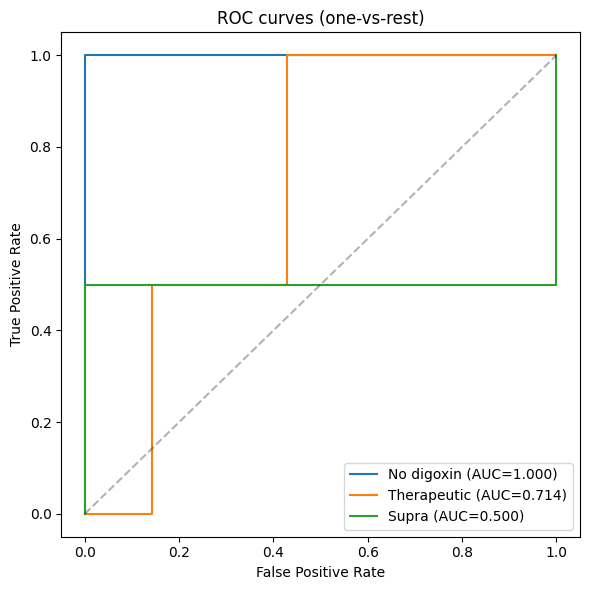

Derived threshold for specificity >= 0.95: 0.194

OVERALL (class 2 vs. rest)

Overall @ threshold=0.194:
  Prevalence:  0.222   (n=2/9)
  Sensitivity: 0.500   (TP=1, FN=1)
  Specificity: 1.000   (TN=7, FP=0)
  PPV:         1.000
  NPV:         0.875

BY SEX

--- Female (n=5) ---
  AUC: 0.000   AP: 0.200

Female @ threshold=0.194:
  Prevalence:  0.200   (n=1/5)
  Sensitivity: 0.000   (TP=0, FN=1)
  Specificity: 1.000   (TN=4, FP=0)
  PPV:           nan
  NPV:         0.800
  Notes:
    - PPV is undefined — model predicts no positives at threshold 0.194 (TP+FP = 0); no cases to check precision on

--- Male (n=4) ---
  AUC: 1.000   AP: 1.000

Male @ threshold=0.194:
  Prevalence:  0.250   (n=1/4)
  Sensitivity: 1.000   (TP=1, FN=0)
  Specificity: 1.000   (TN=3, FP=0)
  PPV:         1.000
  NPV:         1.000

BY AGE

< 65 years: insufficient data (n=6, positives=0)

--- >= 65 years (n=3) ---
  AUC: 0.500   AP: 0.833

>= 65 years @ threshold=0.194:
  Prevalence:  0.667   (n=2/3)
  Sensitiv

In [17]:
# ROC curves
print(f"age_at_ecg_days: min={val_df['age_at_ecg_days'].min():.0f}, "
      f"max={val_df['age_at_ecg_days'].max():.0f}, "
      f"median={val_df['age_at_ecg_days'].median():.0f} "
      f"(median ≈ {val_df['age_at_ecg_days'].median()/365.25:.1f} years)")
plot_roc_curves(full_df)

# Subgroup analysis, focusing on class 2 (supra) as the clinically critical call
used_threshold = subgroup_analysis(
    full_df, target_class=2, target_spec=0.95
)